# 01 Data Access

## Defaults

- Region (North Atlantic): lon=[-80, 10], lat=[0, 70]
- Time range: 2016-01-01 to 2024-12-31

In [2]:
import xarray as xr

In [3]:

xr.backends.list_engines()

{'netcdf4': <NetCDF4BackendEntrypoint>
   Open netCDF (.nc, .nc4 and .cdf) and most HDF5 files using netCDF4 in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.NetCDF4BackendEntrypoint.html,
 'scipy': <ScipyBackendEntrypoint>
   Open netCDF files (.nc, .nc4, .cdf and .gz) using scipy in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ScipyBackendEntrypoint.html,
 'store': <StoreBackendEntrypoint>
   Open AbstractDataStore instances in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.StoreBackendEntrypoint.html,
 'zarr': <ZarrBackendEntrypoint>
   Open zarr files (.zarr) using zarr in Xarray
   Learn more at https://docs.xarray.dev/en/stable/generated/xarray.backends.ZarrBackendEntrypoint.html}

In [4]:
import netCDF4
print(netCDF4.__version__)


1.7.3


In [5]:
# Url to 2019 January 1st
url = "https://www.ncei.noaa.gov/thredds/dodsC/OisstBase/NetCDF/V2.1/AVHRR/201901/oisst-avhrr-v02r01.20190101.nc"
ds = xr.open_dataset(url)

ds = xr.open_dataset(url, engine="netcdf4")  # engine matters
print(ds)
print(list(ds.data_vars))

<xarray.Dataset> Size: 17MB
Dimensions:  (time: 1, zlev: 1, lat: 720, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 8B 2019-01-01T12:00:00
  * zlev     (zlev) float32 4B 0.0
  * lat      (lat) float32 3kB -89.88 -89.62 -89.38 -89.12 ... 89.38 89.62 89.88
  * lon      (lon) float32 6kB 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Data variables:
    anom     (time, zlev, lat, lon) float32 4MB ...
    err      (time, zlev, lat, lon) float32 4MB ...
    ice      (time, zlev, lat, lon) float32 4MB ...
    sst      (time, zlev, lat, lon) float32 4MB ...
Attributes: (12/38)
    source:                          ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pa...
    naming_authority:                gov.noaa.ncei
    cdm_data_type:                   Grid
    date_modified:                   2020-01-18T03:16:00Z
    date_created:                    2020-01-18T03:16:00Z
    processing_level:                NOAA Level 4
    ...                              ...
    summary:                  

In [6]:
print('Data variable: ', list(ds.data_vars))
print('Coordinates: ', list(ds.coords))

Data variable:  ['anom', 'err', 'ice', 'sst']
Coordinates:  ['time', 'lat', 'lon', 'zlev']


In [8]:
# Data inspection

print(sst.attrs)
print("dtype: ", sst.dtype)
print('min/max (raw): ', float(sst.min()), float(sst.max()))

{'long_name': 'Daily sea surface temperature', 'valid_min': -300, 'valid_max': 4500, 'units': 'Celsius', '_ChunkSizes': array([   1,    1,  720, 1440], dtype=int32)}
dtype:  float32
min/max (raw):  -1.7999999523162842 32.459999084472656


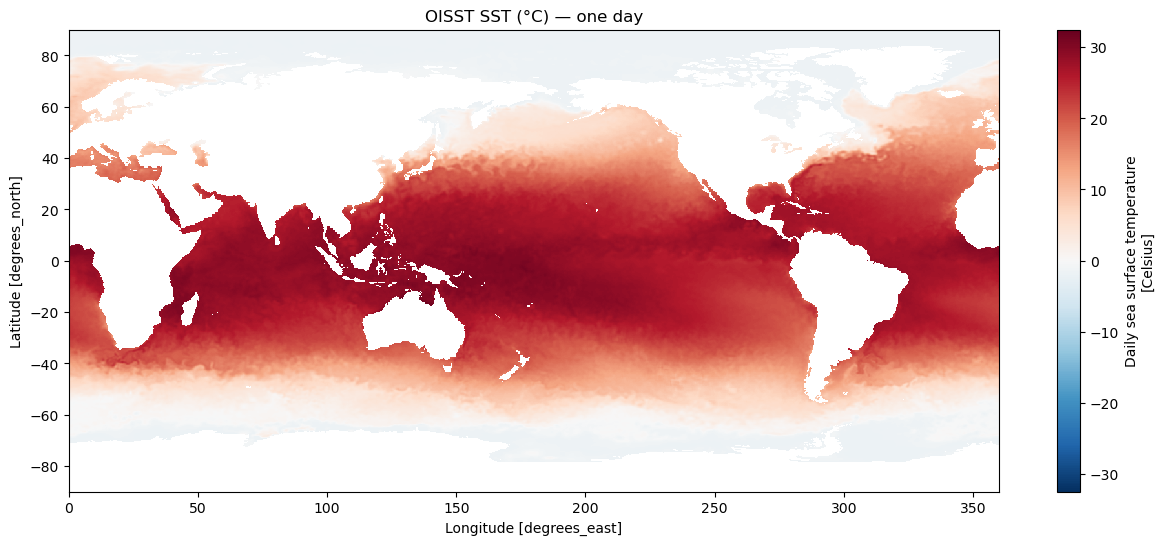

In [9]:
import matplotlib.pyplot as plt

sst0 = ds['sst'].isel(time=0)
sst0.plot(figsize=(15,6))
plt.title('OISST SST (°C) — one day')
plt.show()

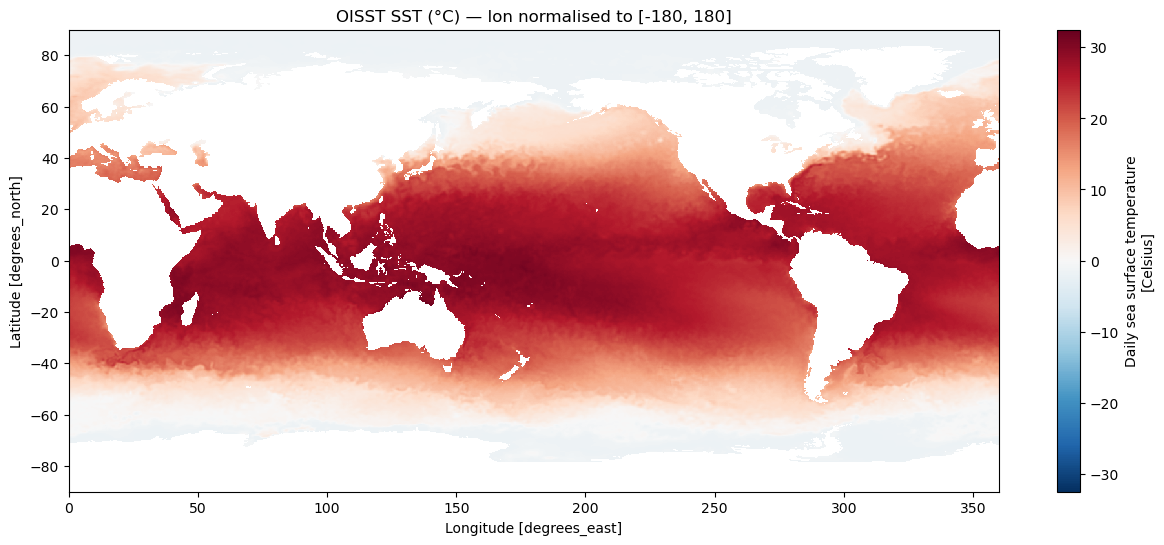

In [10]:
ds2 = ds.assign_coords(ln=(((ds.lon + 180) % 360) - 180)).sortby('lon')
sst0 = ds2['sst'].isel(time=0)

plt.figure(figsize=(15,6))
sst0.plot()
plt.title('OISST SST (°C) — lon normalised to [-180, 180]')
plt.show()

(1, 280, 40)


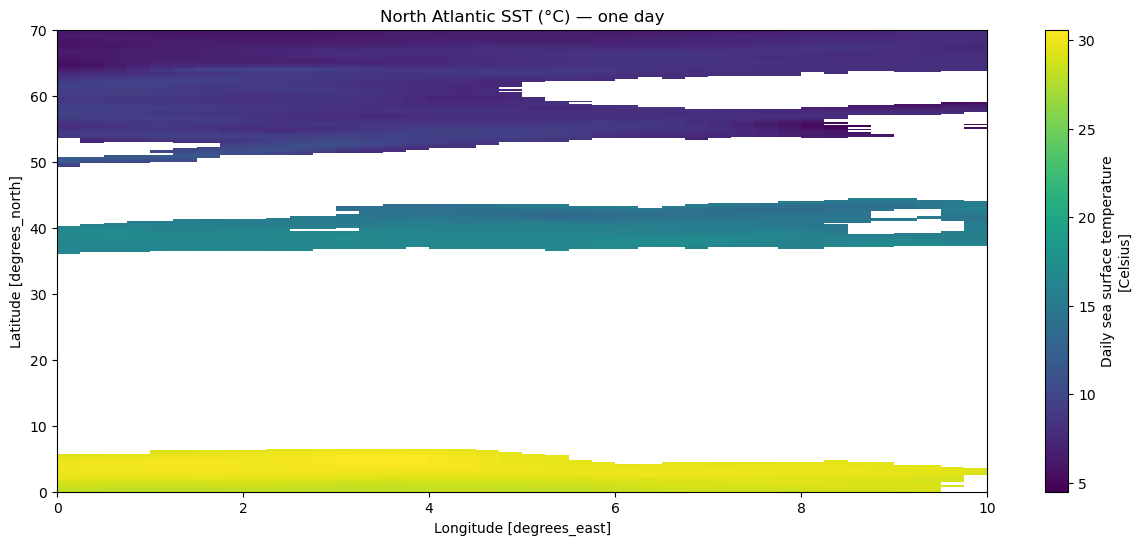

In [11]:
# create subset that is the north atlantic region
# lon in [-80, 10]
# lat in [0,70]

na = ds2.sel(lon=slice(-80, 10), lat=slice(0, 70))
print(na['sst'].isel(time=0).shape)

plt.figure(figsize=(15,6))
na['sst'].isel(time=0).plot()
plt.title('North Atlantic SST (°C) — one day')
plt.show()

In [12]:
# Inspect variables

for v in ds.data_vars:
  print(v, '->', ds[v].dims, ds[v].attrs.get('long_name', ''))
  

anom -> ('time', 'zlev', 'lat', 'lon') Daily sea surface temperature anomalies
err -> ('time', 'zlev', 'lat', 'lon') Estimated error standard deviation of analysed_sst
ice -> ('time', 'zlev', 'lat', 'lon') Sea ice concentration
sst -> ('time', 'zlev', 'lat', 'lon') Daily sea surface temperature


In [13]:
import dask

In [14]:
lon_min = float(ds.lon.min())
lon_max = float(ds.lon.max())
print(lon_min, lon_max)

0.125 359.875


In [15]:
# CHoosing subset to be the antartic, close to the Casey/Davis/Mawson (Australia) posts
# 	lat: -75 to -60 , lon: 50 to 130
antarctic = ds.sel(
    lat=slice(-75, -60),
    lon=slice(50, 130)
)
print(antarctic["sst"].shape)

(1, 1, 60, 320)


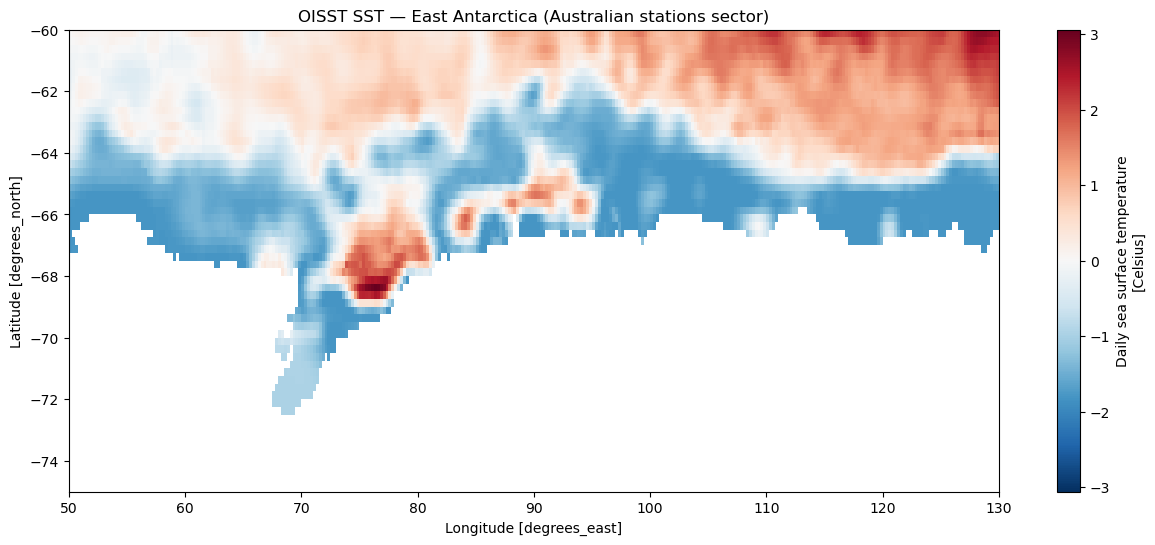

In [16]:
plt.figure(figsize=(15, 6))
antarctic['sst'].isel(time=0).plot()
plt.title("OISST SST — East Antarctica (Australian stations sector)")
plt.show()

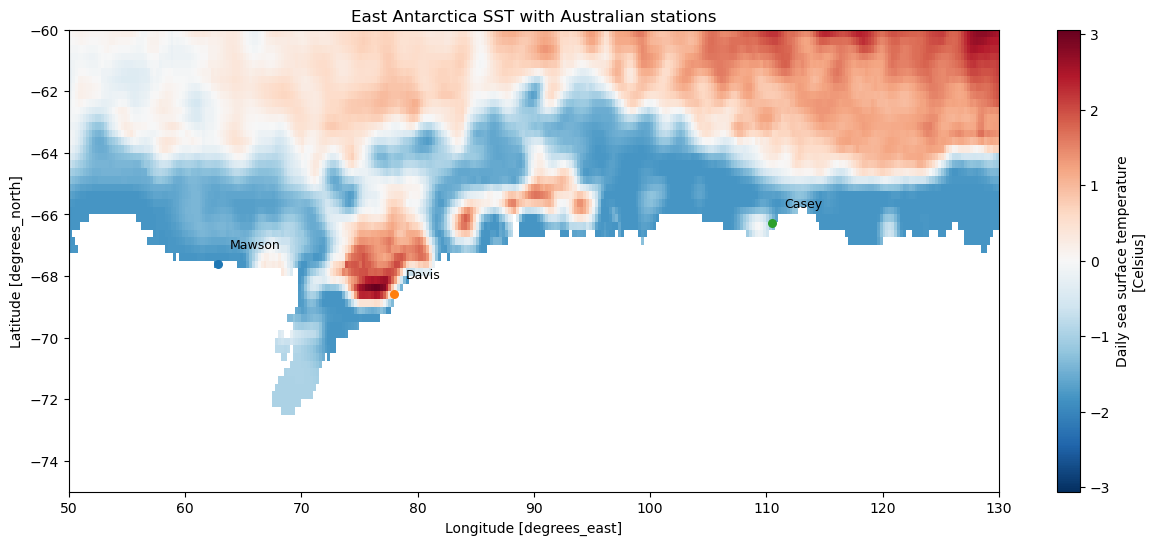

In [17]:
stations ={
  "Mawson": (-67.6, 62.8667),
  "Davis":  (-68.577, 77.97),
  "Casey":  (-66.2822, 110.5267)
}

sst0 = antarctic['sst'].isel(time=0)

plt.figure(figsize=(15,6))
sst0.plot()
for name, (lat, lon), in stations.items():
  plt.scatter(lon, lat, s=30)
  plt.text(lon+1, lat+0.5, name, fontsize=9)
plt.title("East Antarctica SST with Australian stations")
plt.show()

In [20]:
print('Data variable: ', list(antarctic.data_vars))
print('Coordinates: ', list(antarctic.coords))

Data variable:  ['anom', 'err', 'ice', 'sst']
Coordinates:  ['time', 'lat', 'lon', 'zlev']


In [19]:
# Moving from one day to one month 

urls = [f"https://www.ncei.noaa.gov/thredds/dodsC/OisstBase/NetCDF/V2.1/AVHRR/201901/oisst-avhrr-v02r01.201901{d:02d}.nc"
    for d in range(1, 32)]
ds_month = xr.open_mfdataset(urls, combine='by_coords', engine='netcdf4')
ds_month = ds_month.assign_coords(lon=(((ds_month.lon + 180) % 360) - 180)).sortby('lon')
an_month = ds_month.sel(lon=slice(50, 130), lat=slice(-75, -60))

print(an_month)

<xarray.Dataset> Size: 10MB
Dimensions:  (time: 31, zlev: 1, lat: 60, lon: 320)
Coordinates:
  * time     (time) datetime64[ns] 248B 2019-01-01T12:00:00 ... 2019-01-31T12...
  * zlev     (zlev) float32 4B 0.0
  * lat      (lat) float32 240B -74.88 -74.62 -74.38 ... -60.62 -60.38 -60.12
  * lon      (lon) float32 1kB 50.12 50.38 50.62 50.88 ... 129.4 129.6 129.9
Data variables:
    anom     (time, zlev, lat, lon) float32 2MB dask.array<chunksize=(1, 1, 60, 320), meta=np.ndarray>
    err      (time, zlev, lat, lon) float32 2MB dask.array<chunksize=(1, 1, 60, 320), meta=np.ndarray>
    ice      (time, zlev, lat, lon) float32 2MB dask.array<chunksize=(1, 1, 60, 320), meta=np.ndarray>
    sst      (time, zlev, lat, lon) float32 2MB dask.array<chunksize=(1, 1, 60, 320), meta=np.ndarray>
Attributes: (12/38)
    source:                          ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pa...
    naming_authority:                gov.noaa.ncei
    cdm_data_type:                   Grid
    date_modif

In [22]:
an_month.to_zarr("na_oisst_201901.zarr", mode="w")
# reload later instantly with na_month = xr.open_zarr("na_oisst_201901.zarr")

/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [25]:
# Only 1 dimension in zlev, so for simplicity squeeze out
an_month = an_month.squeeze('zlev', drop=True)

In [ ]:
# Name Variables

sst = an_month['sst']       # Core field F(t,lat,lon)
ice = an_month['ice']       # Ice mask
err = an_month['err']       # Errors/uncertainty

# Ice Mask

Now choosing an ice threshold, and maskign the field for lower ice concentration.
This is to reduce chances of anomaly detector just finding the ice edge

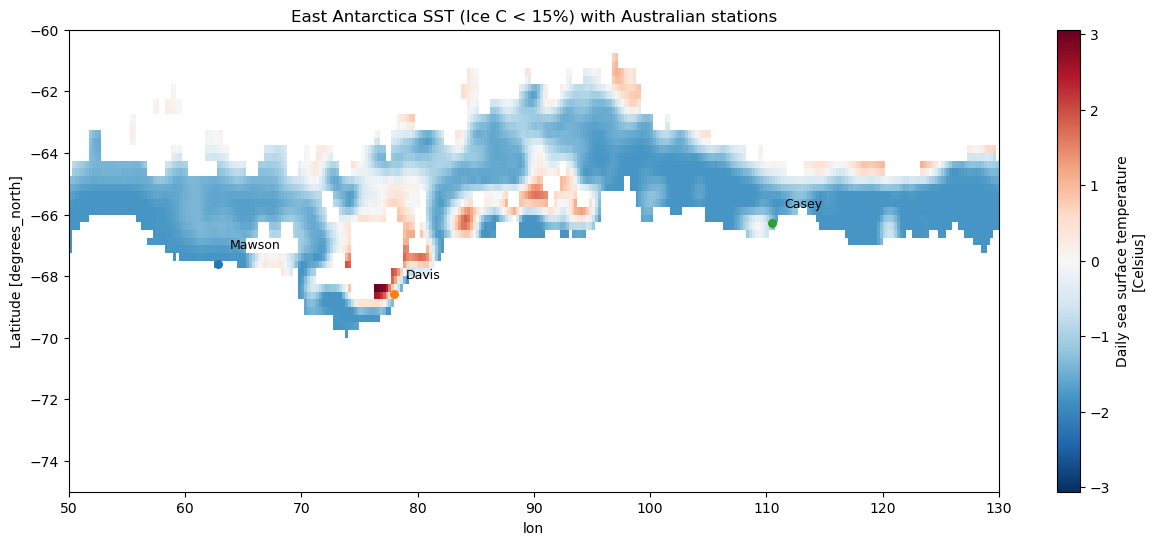

In [29]:
ICE_THRESHOLD = 15          # Percentage ice concentration

an_clean = an_month["sst"].where(antarctic["ice"] < ICE_THRESHOLD)

sst0 = an_clean.isel(time=0)

plt.figure(figsize=(15,6))
sst0.plot()
for name, (lat, lon), in stations.items():
  plt.scatter(lon, lat, s=30)
  plt.text(lon+1, lat+0.5, name, fontsize=9)
plt.title("East Antarctica SST (Ice C < 15%) with Australian stations")
plt.show()

# Moving analysis to 5 years

In [33]:
def oisst_url(dt):
    ymd = dt.strftime("%Y%m%d")
    y_m = dt.strftime("%Y%m")
    return (
        "https://www.ncei.noaa.gov/thredds/dodsC/"
        f"OisstBase/NetCDF/V2.1/AVHRR/{y_m}/oisst-avhrr-v02r01.{ymd}.nc"
    )

In [39]:
import pandas as pd

def oisst_urls_for_month(year: int, month: int):
    dates = pd.date_range(f"{year:04d}-{month:02d}-01",
                          pd.Timestamp(year=year, month=month, day=1) + pd.offsets.MonthEnd(0),
                          freq="D")
    urls = []
    for dt in dates:
        ymd = dt.strftime("%Y%m%d")
        ym  = dt.strftime("%Y%m")
        urls.append(
            "https://www.ncei.noaa.gov/thredds/dodsC/"
            f"OisstBase/NetCDF/V2.1/AVHRR/{ym}/oisst-avhrr-v02r01.{ymd}.nc"
        )
    return urls

In [40]:
LON_SLICE = slice(50, 130)
LAT_SLICE = slice(-75, -60)

In [41]:
import xarray as xr
import os

store = "antarctic_oisst_2016_2020.zarr"
if os.path.exists(store):
    # if you want a fresh rebuild:
    # import shutil; shutil.rmtree(store)
    pass

first = True

for year in range(2016, 2021):
    for month in range(1, 13):
        urls = oisst_urls_for_month(year, month)

        ds_m = xr.open_mfdataset(
            urls,
            combine="by_coords",
            engine="netcdf4",          # use whatever engine successfully loaded earlier
            parallel=False             # IMPORTANT: don't hammer the server
        )

        # lon normalise (optional, but consistent with your plotting)
        ds_m = ds_m.assign_coords(lon=(((ds_m.lon + 180) % 360) - 180)).sortby("lon")

        # subset + drop zlev
        ds_m = ds_m.sel(lon=LON_SLICE, lat=LAT_SLICE).squeeze("zlev", drop=True)

        # rechunk for writing
        ds_m = ds_m.chunk({"time": 31, "lat": 60, "lon": 320})

        # write / append
        if first:
            ds_m.to_zarr(store, mode="w", consolidated=True)
            first = False
        else:
            ds_m.to_zarr(store, mode="a", append_dim="time", consolidated=True)

        print(f"Wrote {year}-{month:02d} ({ds_m.sizes['time']} days)")

/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Wrote 2016-01 (31 days)


/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Wrote 2016-02 (29 days)


/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


...

Wrote 2020-10 (31 days)


/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Wrote 2020-11 (30 days)


/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/zarr/api/asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Wrote 2020-12 (31 days)


In [42]:
# Reload locally

antarctic = xr.open_zarr("antarctic_oisst_2016_2020.zarr", consolidated=True)
print(antarctic)

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 1827, lat: 60, lon: 320)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2016-01-01T12:00:00 ... 2020-12-31T12...
  * lat      (lat) float32 240B -74.88 -74.62 -74.38 ... -60.62 -60.38 -60.12
  * lon      (lon) float32 1kB 50.12 50.38 50.62 50.88 ... 129.4 129.6 129.9
Data variables:
    anom     (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
    err      (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
    ice      (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
    sst      (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                     CF-1.6, ACDD-1.3
    title:                           NOAA/NCEI 1/4 Degree Daily Optimum Inter...
    references:                      Reynolds, et al.(2007) Daily High-Resolu...
    source:                          IC

In [43]:
ICE_THRESHOLD = 15
sst_clean = antarctic["sst"].where(antarctic["ice"] < ICE_THRESHOLD)

In [46]:
# CHeck min and max temp

sst0 = sst.isel(time=0)
print(float(sst0.min()), float(sst0.max()))

-1.7999999523162842 3.059999942779541


In [47]:
# Load
import xarray as xr

STORE = "antarctic_oisst_2016_2020.zarr"  # cache path
ds = xr.open_zarr(STORE)  # fast local

ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 1827, lat: 60, lon: 320)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2016-01-01T12:00:00 ... 2020-12-31T12...
  * lat      (lat) float32 240B -74.88 -74.62 -74.38 ... -60.62 -60.38 -60.12
  * lon      (lon) float32 1kB 50.12 50.38 50.62 50.88 ... 129.4 129.6 129.9
Data variables:
    anom     (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
    err      (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
    ice      (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
    sst      (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                     CF-1.6, ACDD-1.3
    title:                           NOAA/NCEI 1/4 Degree Daily Optimum Inter...
    references:                      Reynolds, et al.(2007) Daily High-Resolu...
    source:                          ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pa...
    id:                              oisst-avhrr-v02r01.20201201.nc
    naming_authority:                gov.noaa.ncei
    ...                              ...
    time_coverage_end:               2020-12-01T23:59:59Z
    metadata_link:                   https://doi.org/10.25921/RE9P-PT57
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v2.0
    comment:                         Data was converted from NetCDF-3 to NetC...
    sensor:                          Thermometer, AVHRR
    DODS_EXTRA.Unlimited_Dimension:  time

In [ ]:
# standardise dataset

# Drop zlev 
if "zlev" in ds.dims:
  ds = ds.squeeze("zlev", drop=True)

# Ensure latitude is increasing 
if ds.lat[0] > ds.lat[-1]:
  ds = ds.sortby("lat")
  
# ENsure longitude is increasing
ds = ds.sortby("lon")

ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 1827, lat: 60, lon: 320)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2016-01-01T12:00:00 ... 2020-12-31T12...
  * lat      (lat) float32 240B -74.88 -74.62 -74.38 ... -60.62 -60.38 -60.12
  * lon      (lon) float32 1kB 50.12 50.38 50.62 50.88 ... 129.4 129.6 129.9
Data variables:
    anom     (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
    err      (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
    ice      (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
    sst      (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                     CF-1.6, ACDD-1.3
    title:                           NOAA/NCEI 1/4 Degree Daily Optimum Inter...
    references:                      Reynolds, et al.(2007) Daily High-Resolu...
    source:                          ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pa...
    id:                              oisst-avhrr-v02r01.20201201.nc
    naming_authority:                gov.noaa.ncei
    ...                              ...
    time_coverage_end:               2020-12-01T23:59:59Z
    metadata_link:                   https://doi.org/10.25921/RE9P-PT57
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v2.0
    comment:                         Data was converted from NetCDF-3 to NetC...
    sensor:                          Thermometer, AVHRR
    DODS_EXTRA.Unlimited_Dimension:  time

In [62]:
sst_raw = ds["sst"]

valid_frac = sst_raw.notnull().mean("time")

p = 0.2  # 20% of days have valid SST
ocean_mask = valid_frac >= p

print("Usable spatial fraction:", float(ocean_mask.mean()))

Usable spatial fraction: 0.48291666666666666


In [ ]:
ICE_THRESHOLD = 0.15  # 15% ice, fractional

sst = (
    sst_raw
    .where(ocean_mask)
    .where(ds["ice"] < ICE_THRESHOLD)
)

print("NaN fraction after ocean + ice mask:", float(sst.isnull().mean()))

NaN fraction after ocean + ice mask: 0.9996705950100346


In [66]:
ice = ds["ice"]

valid_frac = sst_raw.notnull().mean("time")
ocean_mask = valid_frac >= 0.2

def open_water_fraction(thr):
  return float((ice.where(ocean_mask) < thr).mean())
for thr in [0.15, 0.30, 0.50, 0.80, 1.00]: 
  print(f"for threshould: {thr}, fraction of open water is: {open_water_fraction(thr)}")


for threshould: 0.15, fraction of open water is: 0.0003294049899653348
for threshould: 0.3, fraction of open water is: 0.02336375091224229
for threshould: 0.5, fraction of open water is: 0.059162932174785625
for threshould: 0.8, fraction of open water is: 0.12382506043605182
for threshould: 1.0, fraction of open water is: 0.278588989235541


In [70]:
# Investigating ice content in the summer months

summer = ds["time"].dt.month.isin([12, 1, 2])
sst_summer = sst_raw.sel(time=summer).where(ocean_mask)

ice_summer = ice.sel(time=summer).where(ocean_mask)

print("Open-water fraction summer (<0.15):", float((ice_summer < 0.15).mean()))

Open-water fraction summer (<0.15): 0.0006196994837758112


## change of direction
It seems for th subset selected and cached, the dataset comprises of mostly ice. Therefor it seems efficient to change the aim of the anomaly detection, making ice our basline and forming ressiduals of the ice percentage, using Knn and dayofyear meanclimatology. 

In [3]:
# Load
import xarray as xr

STORE = "antarctic_oisst_2016_2020.zarr"  # cache path
ds = xr.open_zarr(STORE)  # fast local

# standardise dataset

# Drop zlev 
if "zlev" in ds.dims:
  ds = ds.squeeze("zlev", drop=True)

# Ensure latitude is increasing 
if ds.lat[0] > ds.lat[-1]:
  ds = ds.sortby("lat")
  
# ENsure longitude is increasing
ds = ds.sortby("lon")

ds

<xarray.Dataset> Size: 1GB
Dimensions:  (time: 1827, lat: 60, lon: 320)
Coordinates:
  * time     (time) datetime64[ns] 15kB 2016-01-01T12:00:00 ... 2020-12-31T12...
  * lat      (lat) float32 240B -74.88 -74.62 -74.38 ... -60.62 -60.38 -60.12
  * lon      (lon) float32 1kB 50.12 50.38 50.62 50.88 ... 129.4 129.6 129.9
Data variables:
    anom     (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
    err      (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
    ice      (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
    sst      (time, lat, lon) float64 281MB dask.array<chunksize=(31, 60, 320), meta=np.ndarray>
Attributes: (12/38)
    Conventions:                     CF-1.6, ACDD-1.3
    title:                           NOAA/NCEI 1/4 Degree Daily Optimum Inter...
    references:                      Reynolds, et al.(2007) Daily High-Resolu...
    source:                          ICOADS, NCEP_GTS, GSFC_ICE, NCEP_ICE, Pa...
    id:                              oisst-avhrr-v02r01.20201201.nc
    naming_authority:                gov.noaa.ncei
    ...                              ...
    time_coverage_end:               2020-12-01T23:59:59Z
    metadata_link:                   https://doi.org/10.25921/RE9P-PT57
    ncei_template_version:           NCEI_NetCDF_Grid_Template_v2.0
    comment:                         Data was converted from NetCDF-3 to NetC...
    sensor:                          Thermometer, AVHRR
    DODS_EXTRA.Unlimited_Dimension:  time

In [4]:
# Keeping all open water
ice_raw = ds["ice"]



In [5]:
# Daily mean 
ice_daily = ice_raw.resample(time="1D").mean()

In [6]:
# Climatolgoy
clim_doy = ice_daily.groupby("time.dayofyear").mean("time")

In [7]:
# Broudcast climatology back onto the full time acxis

ice_anom = ice_daily.groupby("time.dayofyear") - clim_doy


In [8]:
# Package inro a dataset and keep metadata tidy
anom_ds = xr.Dataset(
  data_vars={
    "ice_daily": ice_daily,
    "ice_clim_doy": clim_doy,
    "ice_anom": ice_anom
  }
)

anom_ds["ice_anom"].attrs.update({
  "long_name": "Sea-ice concentration anomaly",
  "description": "Daily ICE minus day-of-year climatology over record (2016-2021)"
})

In [9]:
# Dropping the leap year (feb 29)
is_feb29 = (ice_daily.time.dt.month == 2) & (ice_daily.time.dt.day == 29)
ice_noleap = ice_daily.sel(time=~is_feb29)

clim_doy_365 = ice_noleap.groupby("time.dayofyear").mean("time")
ice_anom_365 = ice_noleap.groupby("time.dayofyear") - clim_doy_365

If deciding to train a model with a larger dataset (e.g. 20 years) I would consider removing seasonal slow drift:

In [10]:
'''# 1) Create numeric time coordinate in days since start (float)
t0 = ice_anom_365.time[0]
t_days = (ice_anom_365.time - t0) / xr.timedelta64(1, "D")
ice_anom_365 = ice_anom_365.assign_coords(t_days=("time", t_days.data))

# 2) Fit a linear trend at each grid cell: anomaly ≈ a + b * t_days
fit = ice_anom_365.polyfit(dim="time", deg=1, skipna=True)

# fit.polyfit_coefficients has coords: degree (0,1), lat, lon (or y,x)
b = fit.polyfit_coefficients.sel(degree=1)  # slope per day
a = fit.polyfit_coefficients.sel(degree=0)  # intercept

# 3) Build the fitted trend field and subtract
trend = a + b * ice_anom_365["t_days"]
ice_anom_detrended = ice_anom_365 - trend'''

'# 1) Create numeric time coordinate in days since start (float)\nt0 = ice_anom_365.time[0]\nt_days = (ice_anom_365.time - t0) / xr.timedelta64(1, "D")\nice_anom_365 = ice_anom_365.assign_coords(t_days=("time", t_days.data))\n\n# 2) Fit a linear trend at each grid cell: anomaly ≈ a + b * t_days\nfit = ice_anom_365.polyfit(dim="time", deg=1, skipna=True)\n\n# fit.polyfit_coefficients has coords: degree (0,1), lat, lon (or y,x)\nb = fit.polyfit_coefficients.sel(degree=1)  # slope per day\na = fit.polyfit_coefficients.sel(degree=0)  # intercept\n\n# 3) Build the fitted trend field and subtract\ntrend = a + b * ice_anom_365["t_days"]\nice_anom_detrended = ice_anom_365 - trend'

Did the seasonal–anomaly separation behave the way physics says it should?

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def spatial_dims(da):
    """Guess spatial dims (everything except time-like dims)."""
    return tuple(d for d in da.dims if d not in ("time", "dayofyear"))

def pick_doy(doy):
    """Convenience: ensure integer DOY."""
    return int(doy)
  
stations ={
  "Mawson": (-67.6, 62.8667),
  "Davis":  (-68.577, 77.97),
  "Casey":  (-66.2822, 110.5267)
}

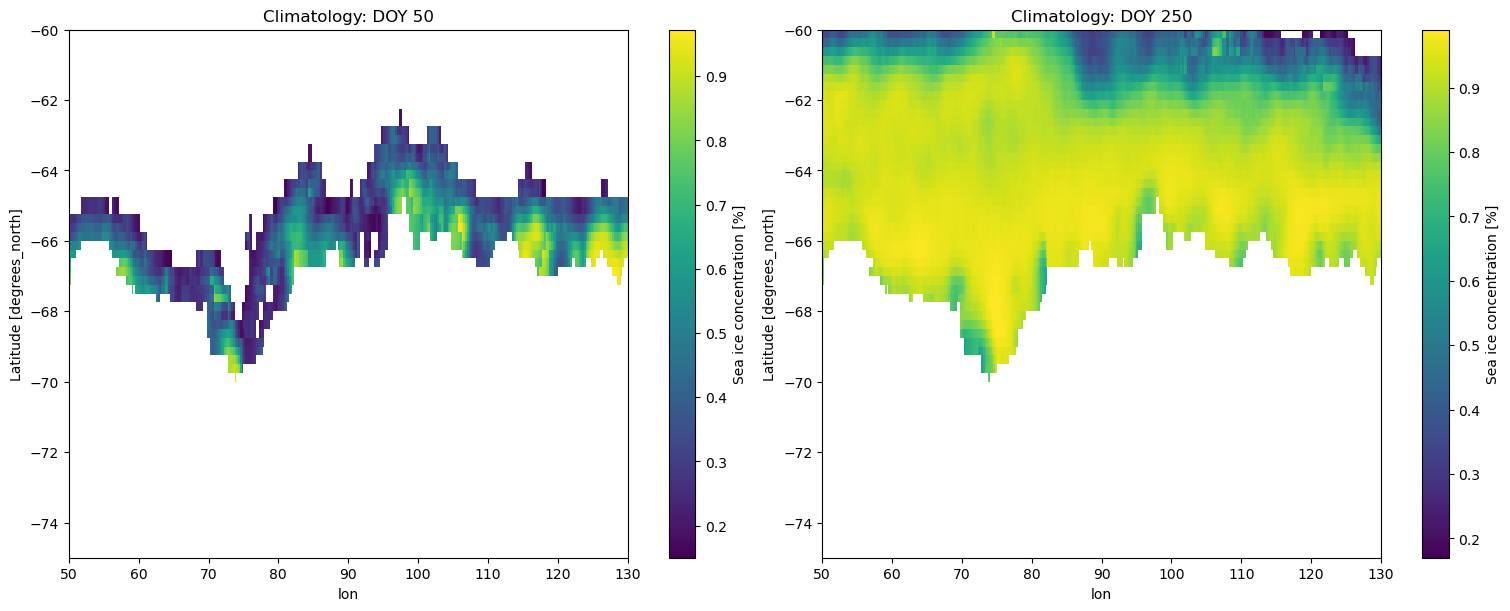

/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [12]:
doys = [50, 250]  # example: summer-ish min and winter-ish max
fig, axes = plt.subplots(1, len(doys), figsize=(15, 6), constrained_layout=True)

for ax, doy in zip(axes, doys):
    m = clim_doy_365.sel(dayofyear=pick_doy(doy))
    m.plot(ax=ax)  # xarray chooses pcolormesh for 2D
    ax.set_title(f"Climatology: DOY {doy}")

plt.show()

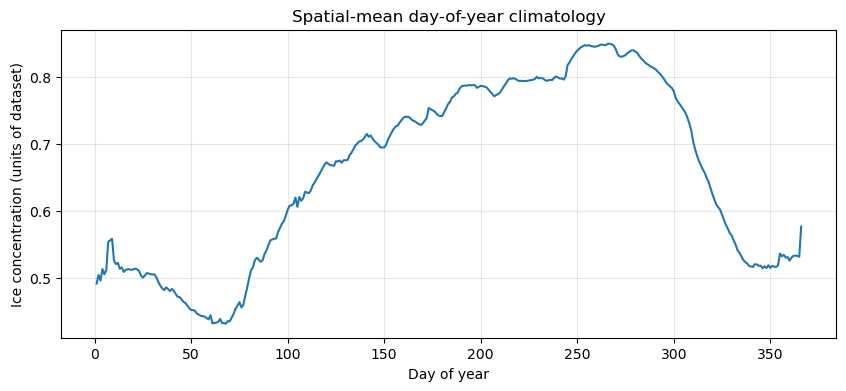

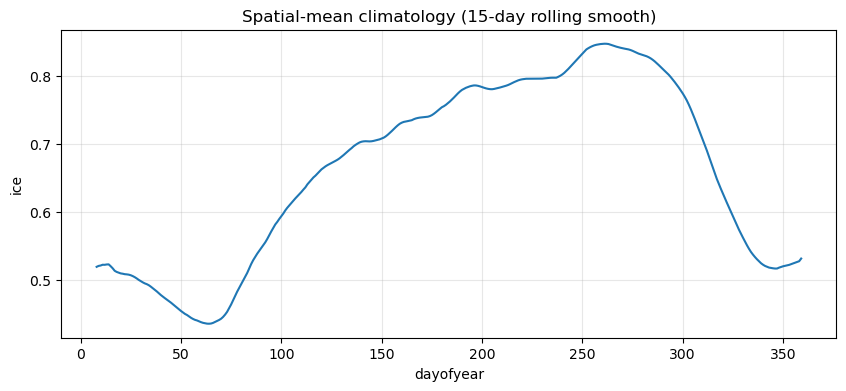

/opt/homebrew/Caskroom/miniforge/base/envs/base_ds/lib/python3.11/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


In [ ]:
sd = spatial_dims(clim_doy_365)
mean_clim = clim_doy_365.mean(dim=sd, skipna=True)

plt.figure(figsize=(10,4))
mean_clim.plot()
plt.title("Spatial-mean day-of-year climatology")
plt.xlabel("Day of year")
plt.ylabel("Ice concentration (units of dataset)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10,4))
mean_clim.rolling(dayofyear=15, center=True).mean().plot()
plt.title("Spatial-mean climatology (15-day rolling smooth)")
plt.grid(True, alpha=0.3)
plt.show()

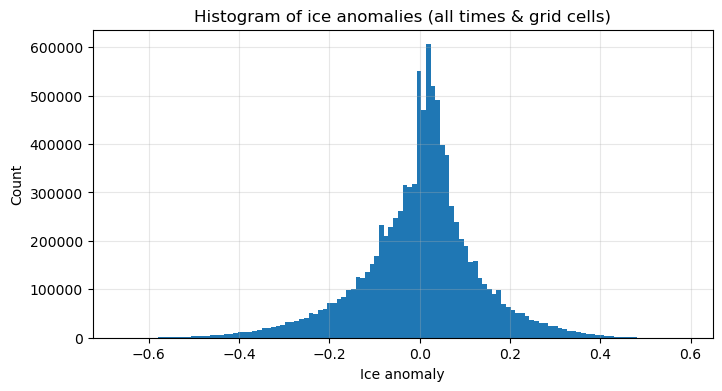

Mean anomaly ~ -2.979e-18, Std ~ 0.1285


In [14]:
plt.figure(figsize=(8,4))
ice_anom_365.plot.hist(bins=120)
plt.title("Histogram of ice anomalies (all times & grid cells)")
plt.xlabel("Ice anomaly")
plt.ylabel("Count")
plt.grid(True, alpha=0.3)
plt.show()

# Quick numerical check
mu = ice_anom_365.mean(skipna=True).values
sigma = ice_anom_365.std(skipna=True).values
print(f"Mean anomaly ~ {mu:.4g}, Std ~ {sigma:.4g}")

LON_SLICE = slice(50, 130)
LAT_SLICE = slice(-75, -60)

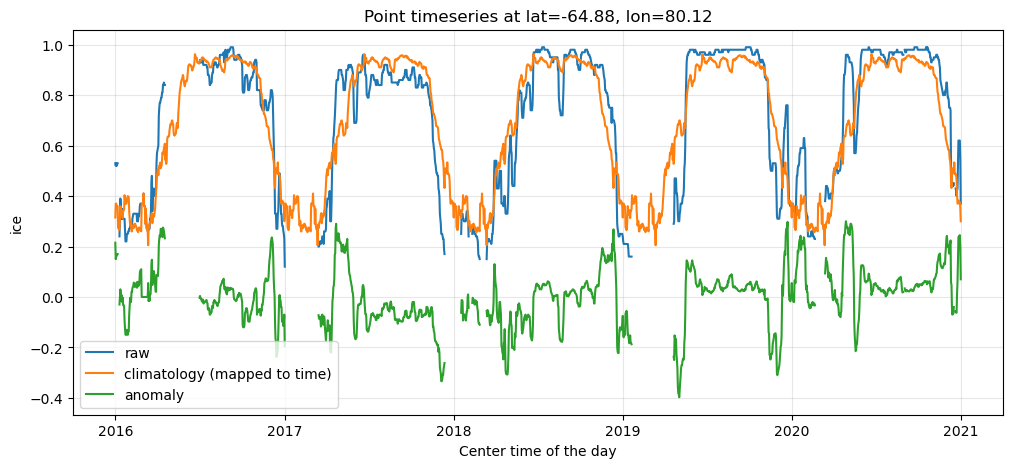

In [15]:
lat0, lon0 = -65, 80 # change these

pt_raw = ice_noleap.sel(lat=lat0, lon=lon0, method="nearest")

# Map the day-of-year climatology back onto the time axis at this point:
pt_clim = clim_doy_365.sel(
    lat=pt_raw.lat, lon=pt_raw.lon, method="nearest"
).sel(
    dayofyear=pt_raw.time.dt.dayofyear
)

pt_anom = pt_raw - pt_clim  # should match ice_anom_365 at that point

plt.figure(figsize=(12,5))
pt_raw.plot(label="raw")
pt_clim.plot(label="climatology (mapped to time)")
pt_anom.plot(label="anomaly")
plt.legend()
plt.title(f"Point timeseries at lat={float(pt_raw.lat):.2f}, lon={float(pt_raw.lon):.2f}")
plt.grid(True, alpha=0.3)
plt.show()

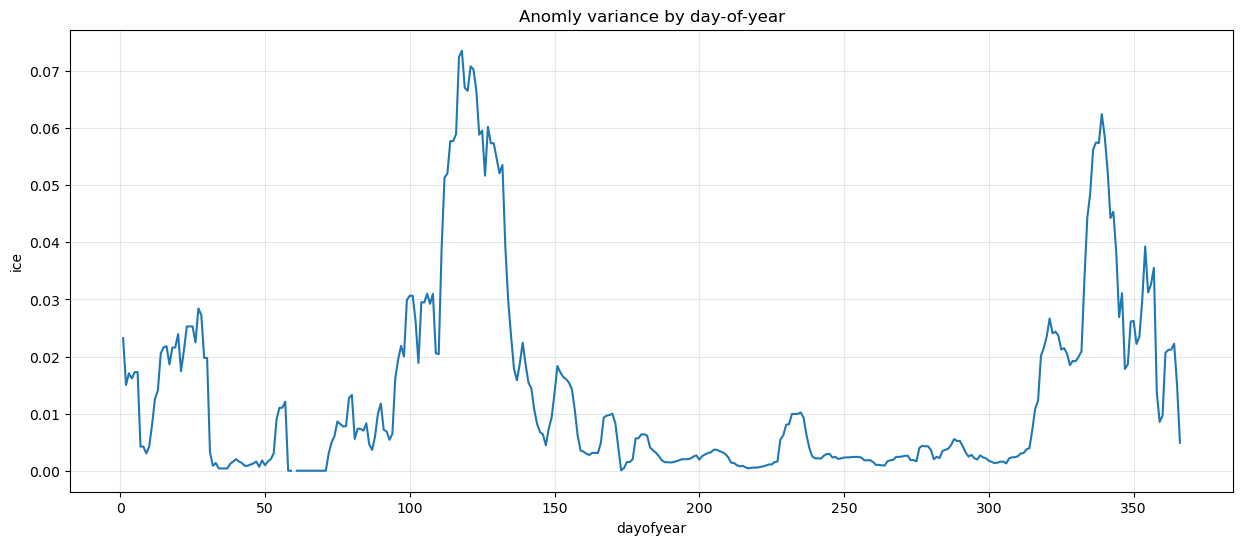

In [16]:
# Variance as a function of day of year
anom_var_doy = ice_anom_365.groupby("time.dayofyear").var("time")

pt_var = anom_var_doy.sel(lat=pt_raw.lat, lon=pt_raw.lon, method="nearest")

plt.figure(figsize=(15, 6))
pt_var.plot()
plt.title("Anomly variance by day-of-year")
plt.grid(True, alpha=0.3)
plt.show()

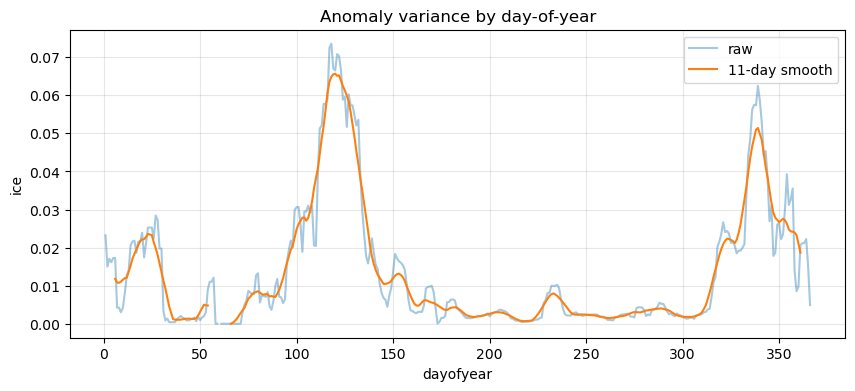

In [17]:
pt_var_smooth = pt_var.rolling(dayofyear=11, center=True).mean()

plt.figure(figsize=(10,4))
pt_var.plot(alpha=0.4, label="raw")
pt_var_smooth.plot(label="11-day smooth")
plt.legend()
plt.title("Anomaly variance by day-of-year")
plt.grid(True, alpha=0.3)
plt.show()

The highest rate of anomolies occoure during the seasonal transition phases

# Exploring Events

Define an event as a contiguous time interval where the anomaly exceeds a threshold:
	•	negative event (low-ice):
$a(t,\mathbf{r}) \le -\theta(\text{doy},\mathbf{r})$
	•	positive event (high-ice):
$a(t,\mathbf{r}) \ge +\theta(\text{doy},\mathbf{r})$

Key decision: is \theta constant, spatially varying, or seasonally varying?

We saw variance depends on DOY, therefore a constant threshould is unfair.

DOY-dependent z-score threshold

Compute a seasonal standard deviation:
$$\sigma(d,\mathbf{r}) = \sqrt{\mathrm{Var}[a(t,\mathbf{r})\mid \text{DOY}=d]}$$

Then define the standardized anomaly
$$z(t,\mathbf{r}) = \frac{a(t,\mathbf{r})}{\sigma(\text{doy}(t),\mathbf{r}) + \varepsilon}$$

Event = contiguous run where z crosses ±k (e.g., k=2).

This automatically respects that transition seasons are noisier.

In [18]:
# Doy-dependent std of anomaly
sigma_doy = ice_anom_365.groupby("time.dayofyear").std("time", skipna=True)
sigma_doy_smooth = sigma_doy.rolling(dayofyear=11, center=True).mean() 

# Map sigma back to time axis
# sigma_t =sigma_doy.sel(dayofyear=ice_anom_365.time.dt.dayofyear)
sigma_t = sigma_doy_smooth.sel(dayofyear=ice_anom_365.time.dt.dayofyear)

# STabilize z-score
eps = 1e-6
z = ice_anom_365 / (sigma_t +eps)
z.name = "ice_z"


In [19]:
# Define candidate events days with threshould

# Threshpld 
k = 2.0
is_low = z<= -k
is_high = z >= k

In [20]:
# Next defining events as occourences that last more than a minimum length of time

min_len = 5 # days

low_persist = is_low.rolling(time=min_len).sum() >= min_len
high_persist =is_high.rolling(time=min_len).sum() >= min_len

# rolling creates Nans at start; filling tith false 
low_persist = low_persist.fillna(False)
high_persist = high_persist.fillna(False)


In [24]:
import numpy as np

# 1) region mask: (lat, lon) boolean
region = (z.lat <= -60) & (z.lat >= -75)

# 2) 1D latitude weights (lat,)
w_lat = np.cos(np.deg2rad(z["lat"]))

# 3) broadcast weights to (lat, lon) by multiplying with a ones-like slice
#    This makes the denominator well-defined on both dims.
w2d = w_lat * xr.ones_like(z.isel(time=0))

# 4) apply region mask
w2d = w2d.where(region)

# 5) weighted mean over space
spatial = ("lat", "lon")
z_reg = (z * w2d).sum(dim=spatial, skipna=True) / w2d.sum(dim=spatial, skipna=True)
z_reg.name = "z_reg"

In [26]:
# Make sure the regional index is in memory (1D)
z_reg = z_reg.compute()

k = 2.0
min_len = 5

flag_low_reg = (z_reg <= -k)  # now non-dask

def label_runs_1d(flag_1d: xr.DataArray) -> xr.DataArray:
    start = flag_1d & (~flag_1d.shift(time=1, fill_value=False))
    run_id = start.cumsum("time")
    return run_id.where(flag_1d, 0).astype("int32")

rid_low = label_runs_1d(flag_low_reg)  # non-dask labels

flag_low_reg = (z_reg <= -k)
rid_low = label_runs_1d(flag_low_reg)

# compute run lengths
run_len_low = flag_low_reg.groupby(rid_low).sum("time")
# keep only runs meeting min_len
good_ids_low = run_len_low.where(run_len_low >= min_len, drop=True).rid_low

# mask to keep only “good” event days
is_low_event_day = xr.apply_ufunc(
    np.isin, rid_low, good_ids_low,
    vectorize=True, dask="parallelized", output_dtypes=[bool]
)

AttributeError: 'DataArray' object has no attribute 'rid_low'

In [ ]:
anom_low_composite = ice_anom_365.sel(time=is_low_event_day).mean("time", skipna=True)
anom_low_composite.plot()

In [ ]:
z_low_composite = z.sel(time=is_low_event_day).mean("time", skipna=True)
z_low_composite.plot()

In [ ]:
def event_table_from_run_id(index: xr.DataArray, run_id: xr.DataArray):
    """
    index: 1D time series (e.g., z_reg)
    run_id: labeled runs (0 for none)
    Returns python list of dicts.
    """
    events = []
    ids = np.unique(run_id.values)
    ids = ids[ids != 0]
    for eid in ids:
        mask = (run_id == eid)
        t = index.time.where(mask, drop=True)
        x = index.where(mask, drop=True)
        events.append({
            "event_id": int(eid),
            "start": str(t.min().values),
            "end": str(t.max().values),
            "duration_days": int(mask.sum().values),
            "min_index": float(x.min().values),
            "mean_index": float(x.mean().values),
        })
    return events

low_events = event_table_from_run_id(z_reg, rid_low.where(is_low_event_day, 0))
low_events[:5]